In [50]:
from mnist_generator import TiledMNISTDataset, label_to_index, index_to_label
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from time import time

ARCHITECTURE

In [51]:
# Patch settings
PATCH_SIZE = 14  # mnist imgs are 56x56 pixels and one patch size is 14x14=196pixels
assert 56 % PATCH_SIZE == 0
NUM_PATCHES = (56 // PATCH_SIZE)**2  # 16 patches

# Channel, Embedding and Token Count, Context size
CHANNELS = 1  # grayscale -> equals to 1 channels which is used for setting up the Conv2D-based patch projector
CONTEXT_SIZE = 6  # what is the maximum context length for predictions #start 4 digits end
N_EMBD = 64

# Transformer block+dropout
NUM_BLOCKS = 4
DROPOUT = 0.1
NUM_HEADS = 4

# Training
BATCH_SIZE = 64  # how many independent sequences will we process in parallel?
NUM_EPOCHS = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
LEARNING_RATE_DECAY = 0.9
train = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Define the collate_fn to pad sequences

In [52]:
MAX_TOKENS = 6  # <start> + 4 digits + <end>


def collate_fn(batch):
    images, input_seqs, target_seqs = zip(*batch)

    images = torch.stack(images)

    input_seqs = pad_sequence(
        input_seqs, batch_first=True, padding_value=label_to_index["<pad>"])
    target_seqs = pad_sequence(
        target_seqs, batch_first=True, padding_value=label_to_index["<pad>"])

    # Optional: Clip or pad to MAX_TOKENS
    input_seqs = input_seqs[:, :MAX_TOKENS]
    target_seqs = target_seqs[:, :MAX_TOKENS]

    return images, input_seqs, target_seqs

Load the datasets

In [53]:
train_dataset = TiledMNISTDataset(split="train", allow_blanks=True)
test_dataset = TiledMNISTDataset(split="test", allow_blanks=True)

Create data loaders

In [54]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_fn)

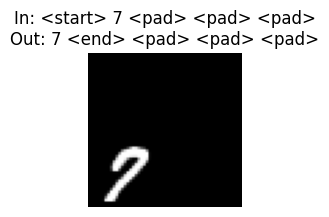

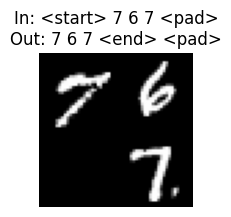

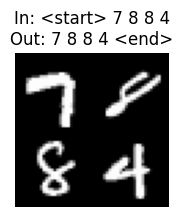

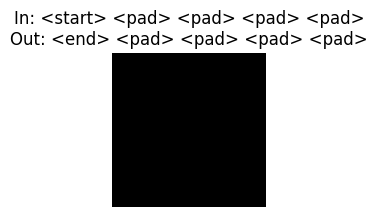

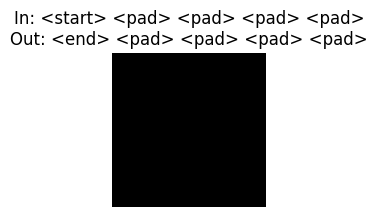

In [55]:
batch = next(iter(train_loader))
images, in_seqs, out_seqs = batch

for i in range(5):
    img = images[i].squeeze()
    input_tokens = [index_to_label[idx.item()] for idx in in_seqs[i]]
    target_tokens = [index_to_label[idx.item()] for idx in out_seqs[i]]

    plt.figure(figsize=(2, 2))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"In: {' '.join(input_tokens)}\nOut: {' '.join(target_tokens)}")
    plt.show()

In [56]:
# Image size (tiled) = 1 x 56 x 56 (2 x 2 grid)
# Encoder input shape = (B, 1, 56, 56)
# Patch size = 14 x 14
# Number of patches = 16
# Decoder input shape = (B, T) where B-batch_size and T = max sequence lenghth in batch
# Target shape = (B, T)
# Vocab size = 13
# Special tokens = <start> <end><pad>
# Padding value 12 <pad>
# Max digits per image 4
# Max sequnce length 6 (<start> d1 d2 d3 d4 <end>)

Patch Embeddings

In [57]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        # example Input of Raw MNIST images (Batch_size=32, Chanel=1, W=56, h=56)
        self._conv2d = nn.Conv2d(
            in_channels=CHANNELS,  # channel=1
            out_channels=N_EMBD,  # n_embd=64 - the dimensional embedding vector
            kernel_size=PATCH_SIZE,  # defines the size of each patch 14x14
            # moves the kernel by 14 pixels = no overlap between patches
            stride=PATCH_SIZE, padding=0)
        # after conv2d each of 16 patches (4x4gid) mapped to 64 features (nr of embeddings)=> (Batch size=32, Emb=64, 4, 4)
        # Flattens [B, 64, 4, 4] → [B, 64, 16]
        self._flatten = nn.Flatten(start_dim=2, end_dim=3)

    def forward(self, x):
        x = self._conv2d(x)  # (B, 1,56,56)->(B,64,4,4)
        x = self._flatten(x)  # -> (B, 64, 16)
        # after permuting the (32,64,4,4) we have (32=Batch,16=patches,64=embedning vector in embedding space) = > Final ViT input: token sequence
        return x.permute(0, 2, 1)  # (B, 16, 16)

Test patching embedding

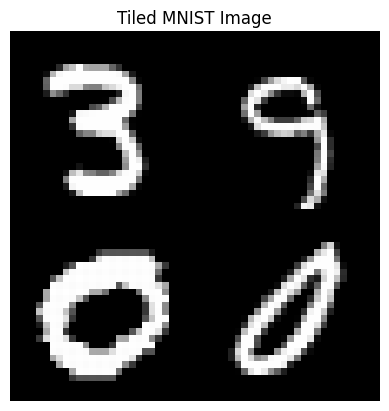

Patch Embedding Output Shape: torch.Size([1, 16, 64])

Patch 0 (Shape: torch.Size([64]) ):
 tensor([-0.4839, -0.1755,  0.2256,  0.1071, -0.0859,  0.2136, -0.2255,  0.1595,
        -0.0748,  0.2740, -0.2765, -0.1277,  0.2483, -0.2338,  0.2334,  0.3853,
         0.5340, -0.0079, -0.1760, -0.0308,  0.1444, -0.3756, -0.3163,  0.2166,
         0.3943, -0.1297,  0.2867,  0.0171,  0.0445,  0.3190,  0.2352, -0.1632,
        -0.1632,  0.0374, -0.4713,  0.2423,  0.1788, -0.1611,  0.5883, -0.0785,
        -0.0529, -0.1339,  0.2582,  0.2303, -0.3073,  0.2149,  0.0187,  0.1380,
         0.2283,  0.2122,  0.3945,  0.1794,  0.0793, -0.1692,  0.0326, -0.0383,
        -0.1043,  0.1634,  0.1834, -0.1105,  0.2161,  0.1808,  0.1499, -0.1651],
       grad_fn=<SelectBackward0>)

Patch 1 (Shape: torch.Size([64]) ):
 tensor([-0.1536, -0.0246,  0.2090,  0.0410,  0.3077,  0.0735, -0.1015, -0.2610,
        -0.2486, -0.2785,  0.2136, -0.0569, -0.0955,  0.4144,  0.2001, -0.0793,
         0.0760,  0.0188, -0.3283, 

In [58]:
# initialize the patch emebeding module
patch_embed = PatchEmbedding()

# Get a single sample (image, input_seq, target_seq)
image, input_seq, target_seq = train_dataset[0]  # image shape: (1, 56, 56)

plt.imshow(image.squeeze(), cmap="gray")
plt.axis("off")
plt.title("Tiled MNIST Image")
plt.show()

# Add batch dimension: shape (1, 1, 56, 56)
image = image.unsqueeze(0)

# Initialize the patch embedding module
patch_embed = PatchEmbedding()

# Get patch embeddings
patches = patch_embed(image)  # shape: (1, 16, 64)

print("Patch Embedding Output Shape:", patches.shape)
# Expecting: torch.Size([1, 16, 64])
patch_0 = patches[0, 0]  # First patch in the sequence
patch_1 = patches[0, 1]  # Second patch

print("\nPatch 0 (Shape:", patch_0.shape, "):\n", patch_0)
print("\nPatch 1 (Shape:", patch_1.shape, "):\n", patch_1)

SELF ATTENTION

In [59]:
class AttentionHead(nn.Module):  # Head
    """ one head of self-attention """
    # Constructor

    def __init__(self, head_size, is_decoder):
        super().__init__()
        self.key = nn.Linear(N_EMBD, head_size, bias=False)
        self.query = nn.Linear(N_EMBD, head_size, bias=False)
        self.value = nn.Linear(N_EMBD, head_size, bias=False)
        self.register_buffer('tril', torch.tril(  # trils is a lower triangular matrix used for masking future tokens in decoder self-attebtion, not needed in Vit or encoder
            torch.ones(CONTEXT_SIZE, CONTEXT_SIZE)))  # shape is T, T
        self.dropout = nn.Dropout(DROPOUT)
        self._is_decoder = is_decoder

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # SHAPE(B T C)
        q = self.query(x)  # SHAPE(B T C)s
        wei = q @ k.transpose(-2, -1) * C**-0.5
        if self._is_decoder:  # only in decoder blocks
            wei = wei.masked_fill(
                self.tril[:T, :T] == 0, float('-inf'))  # (B, T, T)
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v
        return out  # (B, T, head_size)

Multi-Head Attention

In [60]:
# 4 heads where the head size per head is 16 (Embed dim/num of heads)
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, head_size, is_decoder=True):
        super().__init__()

        self.heads = nn.ModuleList(
            [AttentionHead(head_size, is_decoder) for _ in range(NUM_HEADS)])
        self.proj = nn.Linear(head_size * NUM_HEADS, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):

        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out

Cross Attention Head

In [61]:
class CrossAttentionHead(nn.Module):
    """ One head of cross-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(N_EMBD, head_size, bias=False)
        self.query = nn.Linear(N_EMBD, head_size, bias=False)
        self.value = nn.Linear(N_EMBD, head_size, bias=False)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, query_input, encoder_output):
        """
        query_input: shape (B, T_dec, N_EMBD) ← decoder input
        encoder_output: shape (B, T_enc, N_EMBD) ← encoder output (patch tokens)
        """
        B, T_dec, _ = query_input.shape
        T_enc = encoder_output.size(1)

        k = self.key(encoder_output)       # (B, T_enc, head_size)
        q = self.query(query_input)        # (B, T_dec, head_size)
        v = self.value(encoder_output)     # (B, T_enc, head_size)

        # Attention scores
        wei = q @ k.transpose(-2, -1) * (k.size(-1)
                                         ** -0.5)  # (B, T_dec, T_enc)
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        # Weighted sum of values
        out = wei @ v  # (B, T_dec, head_size)
        return out

MultiCrossAttentionHead

In [62]:
class MultiHeadCrossAttention(nn.Module):
    """ Multi-head cross-attention for decoder """

    def __init__(self, head_size):
        super().__init__()
        self.heads = nn.ModuleList([
            CrossAttentionHead(head_size) for _ in range(NUM_HEADS)
        ])
        self.proj = nn.Linear(head_size * NUM_HEADS, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, query_input, encoder_output):
        # Each head processes the inputs in parallel
        out = torch.cat([h(query_input, encoder_output)
                        for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out

In [63]:
class MLP(nn.Module):  # FeedForward where clasification takes place
    """ a simple linear layer followed by a non-linearity """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # first fully connected layer. Expands the feature space (eg from 64 to 256) allowing the network to learn more complex intermediate represenations
            nn.Linear(N_EMBD, 4 * N_EMBD),
            nn.GELU(),  # ViT paper uses GELU # Activation fuctions -Adds non-linearity
            # Projects back down to original embedding dim eg 256 ->64
            nn.Linear(4 * N_EMBD, N_EMBD),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        # passes the input x of shape B x T x N-Embed through the MLP block. Output has the same shape
        return self.net(x)

Self Attention Block

In [64]:
class SelfAttentionBlock(nn.Module):
    def __init__(self, is_decoder=False):
        super().__init__()
        head_size = N_EMBD//NUM_HEADS
        self.attn = MultiHeadAttention(head_size, is_decoder=is_decoder)
        self.mlp = MLP()
        self.ln1 = nn.LayerNorm(N_EMBD)
        self.ln2 = nn.LayerNorm(N_EMBD)

    def forward(self, x):
        x = x+self.attn(self.ln1(x))
        x = x+self.mlp(self.ln2(x))
        return x

CrossAttentionBlock

In [65]:
class CrossAttentionBlock(nn.Module):
    def __init__(self):
        super().__init__()
        head_size = N_EMBD // NUM_HEADS
        self.cross_attn = MultiHeadCrossAttention(head_size)
        self.mlp = MLP()
        self.ln1 = nn.LayerNorm(N_EMBD)
        self.ln2 = nn.LayerNorm(N_EMBD)

    def forward(self, x, encoder_output):
        x = x + self.cross_attn(self.ln1(x), encoder_output)
        x = x + self.mlp(self.ln2(x))
        return x

Transformer Encoder

In [66]:
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbedding()  # outputs (B, 16, 64)
        self.pos_embed = nn.Parameter(torch.randn(
            1, NUM_PATCHES, N_EMBD))  # (1, 16, 64)

        self.blocks = nn.Sequential(
            *[SelfAttentionBlock(is_decoder=False) for _ in range(NUM_BLOCKS)]
        )
        self.ln_final = nn.LayerNorm(N_EMBD)

    def forward(self, x):
        x = self.patch_embed(x)  # (B, 16, 64)
        x = x + self.pos_embed   # Add positional encoding
        x = self.blocks(x)       # Apply transformer encoder blocks
        x = self.ln_final(x)
        return x  # (B, 16, 64)

Transformer Decoder

In [67]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, N_EMBD)
        self.pos_embed = nn.Embedding(CONTEXT_SIZE, N_EMBD)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                SelfAttentionBlock(is_decoder=True),
                CrossAttentionBlock()
            ) for _ in range(NUM_BLOCKS)
        ])

        self.ln_final = nn.LayerNorm(N_EMBD)
        self.output_layer = nn.Linear(N_EMBD, vocab_size)

    def forward(self, x, encoder_output):
        B, T = x.shape
        token_embeddings = self.token_embed(x)  # (B, T, 64)
        positions = torch.arange(T, device=x.device).unsqueeze(0)
        position_embeddings = self.pos_embed(positions)  # (1, T, 64)
        x = token_embeddings + position_embeddings

        for block in self.blocks:
            self_attn, cross_attn = block
            x = self_attn(x)
            x = cross_attn(x, encoder_output)

        x = self.ln_final(x)
        logits = self.output_layer(x)  # (B, T, vocab_size)
        return logits

Transformer MNIST

In [68]:
class TransformerMNIST(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = TransformerEncoder()
        self.decoder = TransformerDecoder(vocab_size)

    def forward(self, image, input_seq):
        encoder_output = self.encoder(image)  # (B, 16, 64)
        logits = self.decoder(input_seq, encoder_output)  # (B, T, vocab_size)
        return logits

In [69]:
model = TransformerMNIST(vocab_size=13)
image, in_seq, target_seq = train_dataset[0]
image = image.unsqueeze(0)         # (1, 1, 56, 56)
in_seq = in_seq.unsqueeze(0)       # (1, T)

logits = model(image, in_seq)      # (1, T, vocab_size)
print(logits.shape)

torch.Size([1, 3, 13])


Greedy decoder Function to evaluate predictions

In [70]:
def greedy_decode(model, image, max_len=6):
    model.eval()
    image = image.unsqueeze(0).to(device)  # (1, 1, 56, 56)

    input_seq = [label_to_index["<start>"]]
    input_tensor = torch.tensor(
        input_seq, dtype=torch.long).unsqueeze(0).to(device)  # (1, 1)

    for _ in range(max_len - 1):  # already has <start>
        with torch.no_grad():
            logits = model(image, input_tensor)  # (1, T, vocab_size)
        # last token prediction
        next_token = torch.argmax(logits[:, -1, :], dim=-1).item()
        input_seq.append(next_token)

        if next_token == label_to_index["<end>"]:
            break

        input_tensor = torch.tensor(
            input_seq, dtype=torch.long).unsqueeze(0).to(device)

    return input_seq

Training LOOP

In [71]:
# Instantiate model
model = TransformerMNIST(vocab_size=13).to(device)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer, gamma=LEARNING_RATE_DECAY)

# Start training
start_t = time()

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for step, (images, input_seq, target_seq) in enumerate(train_loader):
        images, input_seq, target_seq = images.to(
            device), input_seq.to(device), target_seq.to(device)

        # Forward pass
        logits = model(images, input_seq)  # (B, T, vocab_size)

        # Flatten logits and targets for loss
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.view(B * T, V), target_seq.view(B * T))

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Optional: print occasionally
        if step % 100 == 0:
            print(f"Epoch {epoch+1}, Step {step}, Loss: {loss.item():.4f}")

    scheduler.step()
    print(
        f"Epoch {epoch+1} completed. Avg Loss: {total_loss / len(train_loader):.4f}")
    # Greedy inference preview
    model.eval()
    with torch.no_grad():
        test_img, _, test_target = test_dataset[0]
        pred_tokens = greedy_decode(model, test_img)
        pred_labels = [index_to_label[t] for t in pred_tokens]
        target_labels = [index_to_label[t.item()] for t in test_target]

        plt.imshow(test_img.squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(
            f"Pred: {' '.join(pred_labels)}\nTrue: {' '.join(target_labels)}")
        plt.show()

# Save model
torch.save(model.state_dict(), "transformer_mnist.pth")
print(f"Training complete in {round(time() - start_t)}s")

Epoch 1, Step 0, Loss: 2.5273


KeyboardInterrupt: 

Test predictions on the entire dataset


In [ ]:
def evaluate_model(model, dataloader, max_len=6, num_samples_to_show=5):
    model.eval()
    total = 0
    correct = 0
    shown = 0

    with torch.no_grad():
        for images, input_seqs, target_seqs in dataloader:
            B = images.size(0)
            images = images.to(device)
            target_seqs = target_seqs.to(device)

            for i in range(B):
                image = images[i]
                target_seq = target_seqs[i]

                pred_tokens = greedy_decode(model, image, max_len=max_len)

                # Trim padding and end token
                target_list = target_seq.tolist()
                target_trimmed = [
                    t for t in target_list if t != label_to_index["<pad>"]]

                # Compare prediction to ground truth
                if pred_tokens == target_trimmed:
                    correct += 1
                total += 1

                # Optionally show
                if shown < num_samples_to_show:
                    pred_labels = [index_to_label[t] for t in pred_tokens]
                    true_labels = [index_to_label[t] for t in target_trimmed]
                    print("Pred: ", pred_labels)
                    print("True: ", true_labels)
                    plt.imshow(image.cpu().squeeze(), cmap="gray")
                    plt.title(
                        f"Pred: {' '.join(pred_labels)}\nTrue: {' '.join(true_labels)}")
                    plt.axis("off")
                    plt.show()
                    shown += 1

    acc = correct / total * 100
    print(f"Sequence-level Accuracy: {acc:.2f}% ({correct}/{total})")

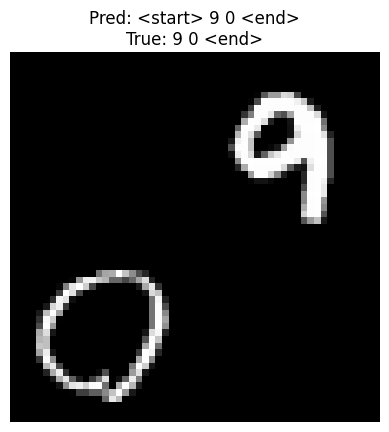

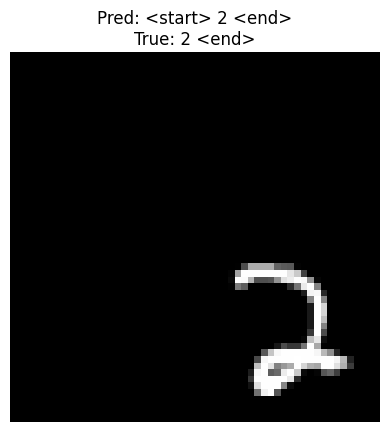

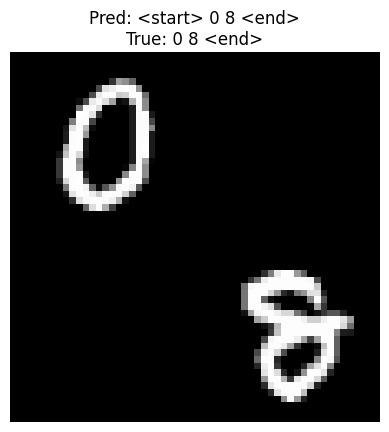

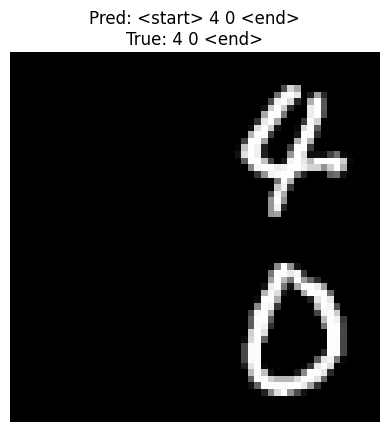

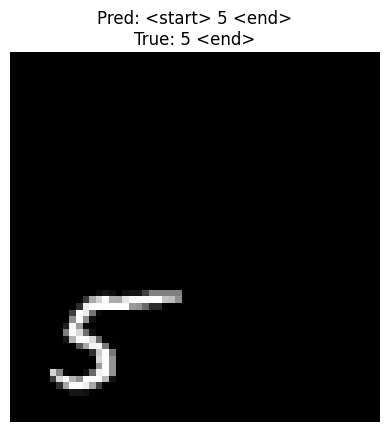

Sequence-level Accuracy: 0.00% (0/10000)


In [72]:
model.load_state_dict(torch.load("transformer_mnist.pth"))
model.to(device)
evaluate_model(model, test_loader, max_len=6, num_samples_to_show=5)

In [73]:
def evaluate_token_accuracy(model, dataloader, max_len=6, num_samples_to_show=5):
    model.eval()
    total_tokens = 0
    correct_tokens = 0
    shown = 0

    with torch.no_grad():
        for images, input_seqs, target_seqs in dataloader:
            B = images.size(0)
            images = images.to(device)
            target_seqs = target_seqs.to(device)

            for i in range(B):
                image = images[i]
                target_seq = target_seqs[i]

                # Generate predictions using greedy decoding
                pred_tokens = greedy_decode(model, image, max_len=max_len)

                # Trim padding for evaluation
                target_trimmed = [
                    t.item() for t in target_seq if t != label_to_index["<pad>"]]

                # Compare token-by-token
                for p, t in zip(pred_tokens, target_trimmed):
                    total_tokens += 1
                    if p == t:
                        correct_tokens += 1

                # Optional: show samples
                if shown < num_samples_to_show:
                    pred_labels = [index_to_label[t] for t in pred_tokens]
                    true_labels = [index_to_label[t] for t in target_trimmed]
                    print("Pred:", pred_labels)
                    print("True:", true_labels)
                    plt.imshow(image.cpu().squeeze(), cmap="gray")
                    plt.title(
                        f"Pred: {' '.join(pred_labels)}\nTrue: {' '.join(true_labels)}")
                    plt.axis("off")
                    plt.show()
                    shown += 1

    acc = correct_tokens / total_tokens * 100
    print(f"Per-token Accuracy: {acc:.2f}% ({correct_tokens}/{total_tokens})")

Pred: ['<start>', '4', '7', '<end>']
True: ['4', '7', '<end>']


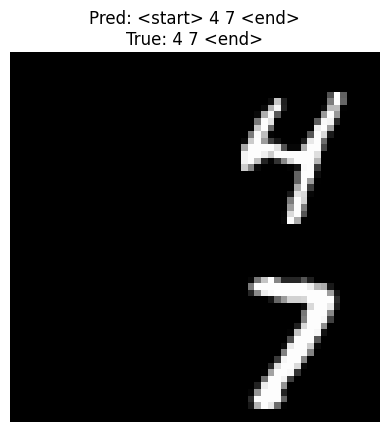

Pred: ['<start>', '0', '5', '0', '<end>']
True: ['0', '5', '0', '<end>']


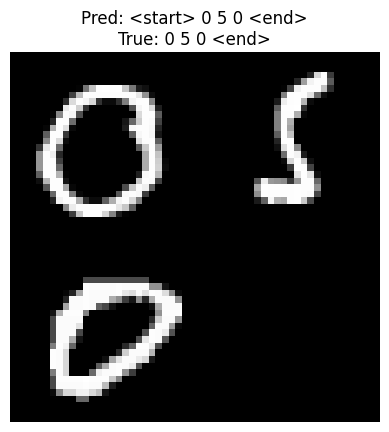

Pred: ['<start>', '4', '3', '0', '<end>']
True: ['4', '3', '0', '<end>']


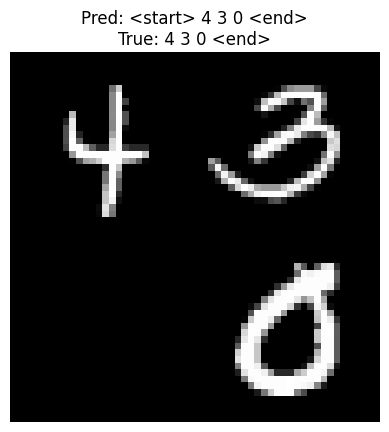

Pred: ['<start>', '2', '7', '4', '2', '<end>']
True: ['2', '7', '4', '2', '<end>']


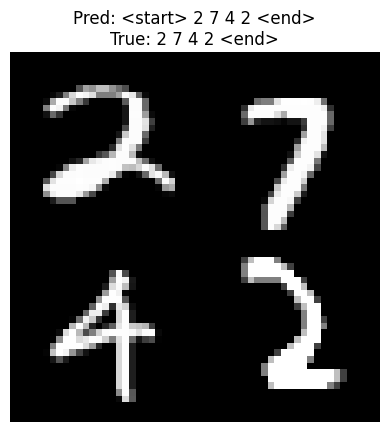

Pred: ['<start>', '4', '<end>']
True: ['4', '<end>']


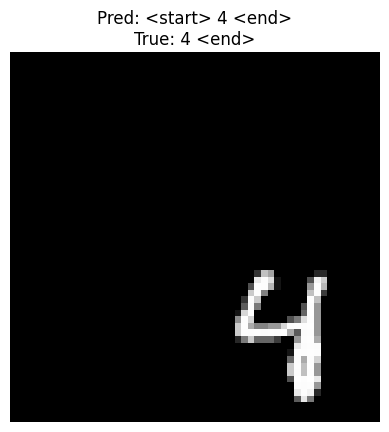

Per-token Accuracy: 4.21% (1252/29705)


In [74]:
evaluate_token_accuracy(model, test_loader)